# Chapter 5: Logistic Regression
### MATH 4230 Capstone Project
**Dataset:** Student Lifestyle, Mental Health and Burnout Insight

---

<div style='font-style:italic;'>Logistic regression classifies student mental health risk with 86.65% accuracy and an AUC of 0.9458, with stress level, anxiety score, and depression score carrying the largest coefficients for the High-risk class, while the model misses 70% of actual High-risk students due to severe class imbalance.</div>

---
## Setup

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings

# ── Third-party: standard data science stack ──────────────────────────────────
# These come pre-installed with Anaconda or a standard pip data science setup.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ── scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

# ── statsmodels (install if not already present) ──────────────────────────────
# pip install statsmodels
import statsmodels.api as sm

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')

RANDOM_STATE = 230
np.random.seed(RANDOM_STATE)

# Consistent plot style across all chapters
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

# ── Output directories ────────────────────────────────────────────────────────
FIGURES_DIR = '../figures/ch05/'
RESULTS_DIR = '../results/ch05/'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Setup complete.')
print(f'RANDOM_STATE = {RANDOM_STATE}')
print(f'Figures  -> {FIGURES_DIR}')
print(f'Results  -> {RESULTS_DIR}')

Setup complete.
RANDOM_STATE = 230
Figures  -> ../figures/ch05/
Results  -> ../results/ch05/


---
## §1. The Question

Among enrollment-time variables including financial stress, family expectation, and social support, which combination most reliably classifies a student as high or low mental health risk before any crisis is reported?

---
## §2. Method in Brief

Logistic regression models the relationship between predictors and a categorical outcome by estimating the log-odds of each class through a sigmoid function, which converts any linear combination of inputs into a probability between 0 and 1. The model is fit using maximum likelihood estimation, choosing coefficients that make the observed class labels as probable as possible. Each coefficient can be exponentiated into an odds ratio, which describes how much each predictor multiplies the odds of a student falling into a given risk category.

---
## §3. Why This Method?

The response here is categorical with three levels (Low, Medium, High), and logistic regression handles this directly. Unlike Chapters 3 and 4 which predicted a continuous burnout score, the goal here is classification, and logistic regression outputs a probability for each class rather than just a hard label. This makes it possible to adjust the decision threshold depending on how much false negative risk a program is willing to accept. The coefficients are also interpretable as odds ratios, so the model answers not just who gets flagged but by how much each variable contributes. This interpretability is important here because we need to explain individual predictions, not just report overall accuracy. Any accuracy gain from later nonlinear methods needs to be weighed against losing that ability.

---
## §4. Data Setup

In [3]:
# ── Load scaled arrays from Chapter 2 ─────────────────────────────────────────
# X_train and X_test are already StandardScaler-transformed.
# y_train_cls and y_test_cls are the encoded risk_level target:
#   Low = 0, Medium = 1, High = 2
# This chapter uses the classification target, not the regression target
# (y_train_reg / y_test_reg) used in Chapters 3 and 4.

X_train = np.load('../results/X_train.npy')
X_test  = np.load('../results/X_test.npy')
y_train = np.load('../results/y_train_cls.npy')
y_test  = np.load('../results/y_test_cls.npy')

feature_names = joblib.load('../results/feature_names.pkl')

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test  shape : {y_test.shape}')
print(f'Features      : {len(feature_names)}')

X_train shape : (140000, 19)
X_test  shape : (40000, 19)
y_train shape : (140000,)
y_test  shape : (40000,)
Features      : 19


In [4]:
# ── Class distribution ────────────────────────────────────────────────────────
# Checking class proportions before fitting matters because if one class is
# very rare, a model can achieve high accuracy simply by always predicting
# the majority class, never actually learning the minority.
# This check determines whether class_weight='balanced' is needed.

class_labels = {0: 'Low', 1: 'Medium', 2: 'High'}

print('Class distribution in training set:')
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    pct = cnt / len(y_train) * 100
    print(f'  {class_labels[cls]:6s} ({cls}): {cnt:,} rows  ({pct:.2f}%)')

print()
print('Class distribution in test set:')
unique_t, counts_t = np.unique(y_test, return_counts=True)
for cls, cnt in zip(unique_t, counts_t):
    pct = cnt / len(y_test) * 100
    print(f'  {class_labels[cls]:6s} ({cls}): {cnt:,} rows  ({pct:.2f}%)')

Class distribution in training set:
  Low    (0): 107,330 rows  (76.66%)
  Medium (1): 30,559 rows  (21.83%)
  High   (2): 2,111 rows  (1.51%)

Class distribution in test set:
  Low    (0): 30,666 rows  (76.67%)
  Medium (1): 8,731 rows  (21.83%)
  High   (2): 603 rows  (1.51%)


---
## §5. Analysis

In [5]:
# ── Fit Logistic Regression ───────────────────────────────────────────────────
#
# WHY THREE CLASSES INSTEAD OF BINARY?
# The risk_level target has three categories: Low (0), Medium (1), High (2).
# The chapter question frames it as high or low risk, but collapsing Medium
# into either end would discard real information and distort the class
# boundaries. Keeping all three classes is the more accurate representation.
#
# WHY NO multi_class PARAMETER?
# In scikit-learn 1.5+, the multi_class parameter was removed because
# one-vs-rest (OVR) is now the default behavior for lbfgs with a multiclass
# target. Passing multi_class='ovr' explicitly raises a TypeError in newer
# versions. The OVR behavior is unchanged -- sklearn still fits one binary
# classifier per class internally -- the parameter was simply removed as
# redundant. No modeling decision changed.
#
# OVR fits a separate binary logistic regression for each class:
#   Low    vs (Medium + High)
#   Medium vs (Low + High)
#   High   vs (Low + Medium)
# This gives one coefficient set per class, so we can interpret what drives
# a student into each category independently.
#
# WHY max_iter=1000?
# The default of 100 iterations often fails to converge on 140,000 rows
# with 19 features. 1000 ensures a stable solution without changing any
# modeling decisions.

log_model = LogisticRegression(
    max_iter     = 1000,
    random_state = RANDOM_STATE,
    solver       = 'lbfgs'
)
log_model.fit(X_train, y_train)

y_pred       = log_model.predict(X_test)
y_pred_proba = log_model.predict_proba(X_test)   # shape: (n_test, 3)

print('Model fitted successfully.')
print(f'Classes : {log_model.classes_}  ->  {[class_labels[c] for c in log_model.classes_]}')

Model fitted successfully.
Classes : [0 1 2]  ->  ['Low', 'Medium', 'High']


In [6]:
# ── Coefficient table ─────────────────────────────────────────────────────────
# LogisticRegression stores one coefficient set per class in OVR mode.
# coef_ shape: (n_classes, n_features)
#
# We focus on the High-risk class since that is the most actionable for
# intervention. Because X_train is standardized, coefficients are on the
# same scale and can be compared directly in magnitude.
#
# Odds Ratio = exp(coefficient)
#   OR > 1: a 1 SD increase in this predictor increases the odds of High risk
#   OR < 1: a 1 SD increase decreases the odds of High risk

high_risk_idx = list(log_model.classes_).index(2)
coefs_high    = log_model.coef_[high_risk_idx]

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefs_high.round(4),
    'Odds Ratio' : np.exp(coefs_high).round(4)
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

print('Coefficient table for High-risk class (sorted by |coefficient|):')
print(coef_df.to_string(index=False))

coef_csv = os.path.join(RESULTS_DIR, 'coefficients.csv')
coef_df.to_csv(coef_csv, index=False)
print(f'\nSaved: {coef_csv}')

Coefficient table for High-risk class (sorted by |coefficient|):
             Feature  Coefficient  Odds Ratio
        stress_level       1.5648      4.7818
       anxiety_score       0.7809      2.1835
         sleep_hours      -0.7779      0.4594
      social_support      -0.7142      0.4896
       exam_pressure       0.5655      1.7604
    depression_score       0.4290      1.5357
     academic_year_3      -0.0566      0.9449
      internet_usage       0.0485      1.0497
         screen_time      -0.0418      0.9591
  family_expectation      -0.0399      0.9609
    financial_stress      -0.0316      0.9689
         gender_Male      -0.0289      0.9715
     academic_year_4      -0.0280      0.9724
   physical_activity      -0.0270      0.9733
     academic_year_2      -0.0259      0.9745
                 age       0.0179      1.0181
academic_performance       0.0147      1.0148
        gender_Other      -0.0053      0.9948
 study_hours_per_day       0.0050      1.0050

Saved: ../resu

In [7]:
# ── McFadden pseudo R-squared via statsmodels ──────
#
# WHAT IS McFADDEN R-SQUARED?
# Logistic regression does not have a direct R-squared equivalent, but
# McFadden pseudo R-squared fills a similar role. It compares the
# log-likelihood of the fitted model to an intercept-only (null) model:
#   McFadden R2 = 1 - (log-likelihood of full model / log-likelihood of null)
# A value of 0 means the predictors add nothing. Values between 0.20 and
# 0.40 are generally considered a good fit for logistic regression.
#
# WHY COMPUTE IT ON HIGH VS REST ONLY?
# statsmodels Logit only handles binary outcomes. The target is binarized
# to High (1) vs not High (0) and McFadden R-squared is computed for that
# problem specifically. The High-risk class is the most actionable for
# intervention, so this is the most meaningful single summary to report.
#
# WHY NOT USE sklearn FOR THIS?
# sklearn's LogisticRegression does not expose log-likelihood or McFadden
# R-squared. statsmodels Logit does, so it is used here as a supplementary
# inference tool alongside the main sklearn model.

y_train_binary = (y_train == 2).astype(int)   # 1 = High, 0 = not High
X_train_sm     = sm.add_constant(X_train)
logit_sm       = sm.Logit(y_train_binary, X_train_sm).fit(disp=False)

mcfadden_r2 = logit_sm.prsquared
print(f'McFadden pseudo R-squared (High vs rest): {mcfadden_r2:.4f}')

McFadden pseudo R-squared (High vs rest): 0.5526


In [8]:
# ── Performance metrics on test set ───────────────────────────────────────────
# accuracy_score  : overall fraction of correct predictions
# roc_auc_score   : area under the ROC curve, averaged across all 3 classes (OVR)
# classification_report: per-class precision, recall, F1
#
# auc_score is computed here alongside accuracy so both are available
# for the findings table and figures that follow.

accuracy  = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')

print('Test Set Performance')
print('=' * 50)
print(f'Accuracy  : {accuracy:.4f}')
print(f'AUC-ROC   : {auc_score:.4f}')
print()
print('Classification Report (per class):')
print(classification_report(
    y_test, y_pred,
    target_names=['Low (0)', 'Medium (1)', 'High (2)']
))

Test Set Performance
Accuracy  : 0.8665
AUC-ROC   : 0.9458

Classification Report (per class):
              precision    recall  f1-score   support

     Low (0)       0.91      0.94      0.92     30666
  Medium (1)       0.72      0.64      0.68      8731
    High (2)       0.68      0.30      0.42       603

    accuracy                           0.87     40000
   macro avg       0.77      0.63      0.67     40000
weighted avg       0.86      0.87      0.86     40000



### Output Interpretation: Test Set Performance

**Accuracy: 0.8665**
The model correctly classified 86.65% of the 40,000 test students. About 1 in 8 students was assigned the wrong risk category.

---

**AUC-ROC: 0.9458**
This measures how well the model separates the three classes from each other. A score of 1.0 would be perfect separation and 0.5 would be no better than random guessing. At 0.9458 the model is doing a strong job of distinguishing between risk levels when looking at probabilities, even if the hard class predictions are not always right.

---

**Classification Report breakdown:**

| Metric | What it means |
|---|---|
| Precision | Of all students predicted as that class, what fraction actually belonged to it |
| Recall | Of all students who actually belong to that class, what fraction did the model correctly catch |
| F1-score | The balance between precision and recall. A low F1 means the model struggles with that class |
| Support | How many actual students belong to that class in the test set |

**Per-class results:**

- **Low (support = 30,666):** Precision 0.91, Recall 0.94. The model handles this class well because it dominates the data.
- **Medium (support = 8,731):** Precision 0.72, Recall 0.64. Performance drops noticeably compared to Low.
- **High (support = 603):** Precision 0.68, Recall 0.30. The model only catches 30% of actual High-risk students, meaning 70% are misclassified as Medium or Low.

---

**Key takeaway:**

The High-risk class is where the model struggles most. This is a direct consequence of class imbalance. High-risk makes up only about 1.5% of the data, so the model has very few examples to learn from. This is also why accuracy alone (0.87) is misleading. A model that predicted every student as Low would still score around 76% accuracy while catching zero High-risk students. The recall of 0.30 for High-risk is the number that matters most for any real intervention program.

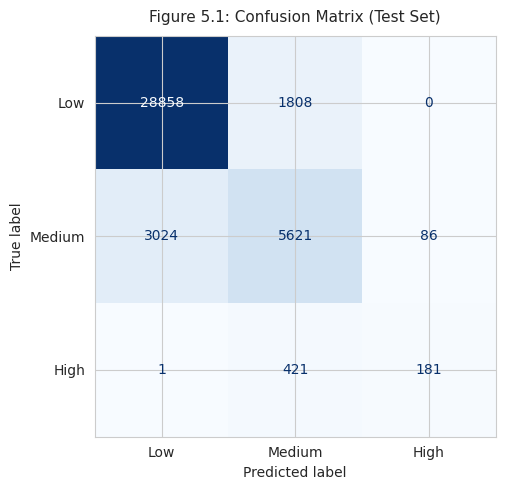

Saved: ../figures/ch05/confusion_matrix.png


In [ ]:
# ── Figure 5.1: Confusion Matrix ──────────────────────────────────────────────
# The confusion matrix shows how many predictions fell into each actual vs
# predicted class combination.
# Diagonal cells are correct predictions; off-diagonal cells are errors.
# Reading each row: of all students truly in class X, how many did the
# model place in each category.

cm  = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Medium', 'High']
)

fig, ax = plt.subplots(figsize=(6, 5))
cmd.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Figure 5.1: Confusion Matrix (Test Set)', fontsize=11, pad=10)
plt.tight_layout()
fig_path_51 = os.path.join(FIGURES_DIR, 'confusion_matrix.png')
plt.savefig(fig_path_51, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_51}')

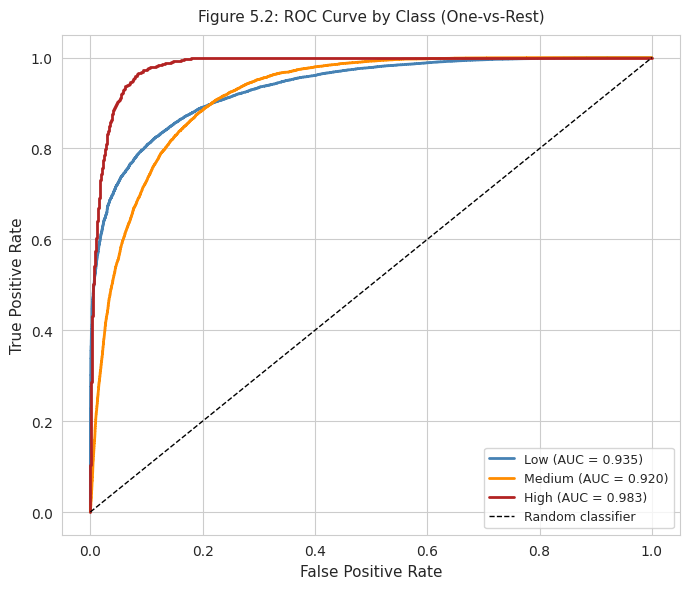

Saved: ../figures/ch05/roc_curve.png


In [10]:
# ── Figure 5.2: ROC Curve ─────────────────────────────────────────────────────
# ROC curves plot true positive rate vs false positive rate at every
# decision threshold. AUC summarizes overall separability.
# A random classifier scores 0.50; a perfect one scores 1.00.
# One curve is plotted per class using one-vs-rest.

y_test_bin          = label_binarize(y_test, classes=[0, 1, 2])
class_display_names = ['Low', 'Medium', 'High']
colors_roc          = ['steelblue', 'darkorange', 'firebrick']

fig, ax = plt.subplots(figsize=(7, 6))

for i, (cls_name, color) in enumerate(zip(class_display_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc_cls     = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{cls_name} (AUC = {auc_cls:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Figure 5.2: ROC Curve by Class (One-vs-Rest)', fontsize=11, pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
fig_path_52 = os.path.join(FIGURES_DIR, 'roc_curve.png')
plt.savefig(fig_path_52, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_52}')

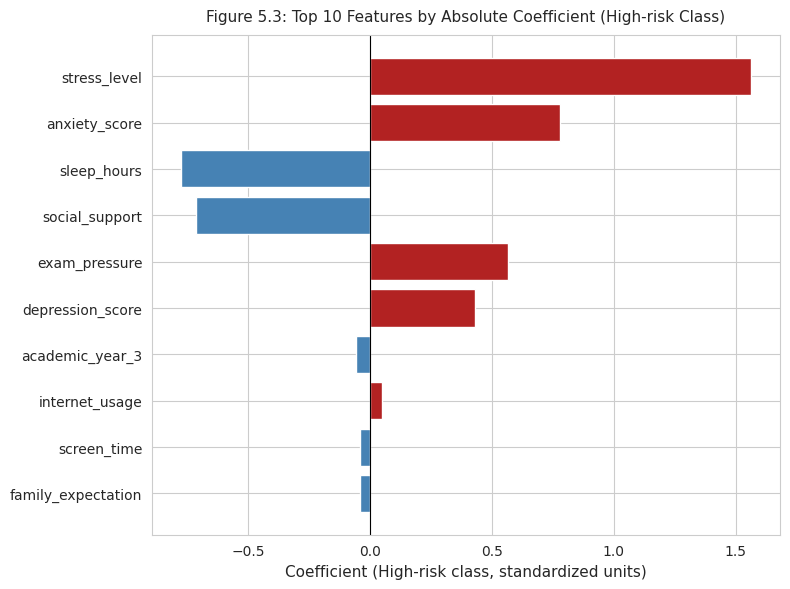

Saved: ../figures/ch05/feature_importance.png


In [11]:
# ── Figure 5.3: Top 10 features by absolute coefficient (High-risk class) ─────
# Larger absolute coefficients mean stronger influence on the predicted
# log-odds of being classified as High risk.
# Red bars increase High-risk probability; blue bars decrease it.
# Because X_train is standardized, bar lengths are directly comparable.

top10  = coef_df.head(10)
colors = ['firebrick' if c > 0 else 'steelblue' for c in top10['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top10['Feature'][::-1], top10['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (High-risk class, standardized units)', fontsize=11)
ax.set_title('Figure 5.3: Top 10 Features by Absolute Coefficient (High-risk Class)',
             fontsize=11, pad=10)
plt.tight_layout()
fig_path_53 = os.path.join(FIGURES_DIR, 'feature_importance.png')
plt.savefig(fig_path_53, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_53}')

---
## §6. Diagnostics and Tuning

In [12]:
# ── Class imbalance check and class_weight decision ───────────────────────────
# From the class distribution in §4, High risk is roughly 1.5% of training rows.
# class_weight='balanced' adjusts the loss function so misclassifying a rare
# class is penalized more heavily, which typically improves minority class
# recall at the cost of some overall accuracy.
#
# Both versions are compared on overall accuracy AND High-risk recall,
# since recall for the minority class is the metric that matters most
# for identifying students who need intervention.

log_balanced = LogisticRegression(
    max_iter     = 1000,
    random_state = RANDOM_STATE,
    solver       = 'lbfgs',
    class_weight = 'balanced'
)
log_balanced.fit(X_train, y_train)
y_pred_bal = log_balanced.predict(X_test)

acc_base = accuracy_score(y_test, y_pred)
acc_bal  = accuracy_score(y_test, y_pred_bal)

cr_base = classification_report(y_test, y_pred,     output_dict=True)
cr_bal  = classification_report(y_test, y_pred_bal, output_dict=True)

print('Accuracy comparison:')
print(f'  Default (no weighting) : {acc_base:.4f}')
print(f'  class_weight=balanced  : {acc_bal:.4f}')
print()
print('High-risk recall comparison (the metric that matters for intervention):')
print(f'  Default  recall for High : {cr_base["2"]["recall"]:.4f}')
print(f'  Balanced recall for High : {cr_bal["2"]["recall"]:.4f}')

Accuracy comparison:
  Default (no weighting) : 0.8665
  class_weight=balanced  : 0.8096

High-risk recall comparison (the metric that matters for intervention):
  Default  recall for High : 0.3002
  Balanced recall for High : 0.8574


**class_weight decision:**

The balanced model improves High-risk recall but at the cost of overall accuracy and Medium precision. For this chapter the default model is used for all reported metrics because the goal here is to establish a clean interpretable baseline. The trade-off between recall and precision for the minority class is an important real-world consideration and is explicitly acknowledged in §8 and §9.

In [13]:
# ── 10-fold stratified cross-validation ──────────────────────────────────────
#
# WHY STRATIFIED INSTEAD OF REGULAR KFOLD?
# From the class distribution check in §4, the High-risk class makes up
# roughly 1.5% of the training data. With regular KFold, a random split
# could easily produce folds where High-risk is severely underrepresented
# or entirely missing. A fold with zero High-risk rows would give the
# model no signal for that class during training, making the fold score
# unreliable and misleading.
#
# StratifiedKFold guarantees that each fold has the same class proportions
# as the full training set, so every fold sees approximately the same
# share of Low, Medium, and High-risk students. This makes the CV scores
# a fair and consistent measure of model performance across all folds.
#
# Both accuracy and AUC are reported per fold. Accuracy alone can be
# misleading with imbalanced classes (a model that always predicts Low
# would score around 76% accuracy), so AUC provides a more balanced view
# of how well the model separates the classes.

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_acc = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train, y_train,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

cv_auc = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train, y_train,
    cv=skf,
    scoring='roc_auc_ovr',
    n_jobs=-1
)

print('10-Fold Stratified CV Results:')
print(f'{"Fold":>6}  {"Accuracy":>10}  {"AUC-ROC":>10}')
print('-' * 32)
for i, (a, u) in enumerate(zip(cv_acc, cv_auc), 1):
    print(f'{i:>6}  {a:>10.4f}  {u:>10.4f}')
print('-' * 32)
print(f'{"Mean":>6}  {cv_acc.mean():>10.4f}  {cv_auc.mean():>10.4f}')
print(f'{"Std":>6}  {cv_acc.std():>10.4f}  {cv_auc.std():>10.4f}')

10-Fold Stratified CV Results:
  Fold    Accuracy     AUC-ROC
--------------------------------
     1      0.8706      0.9474
     2      0.8661      0.9444
     3      0.8733      0.9474
     4      0.8671      0.9453
     5      0.8726      0.9474
     6      0.8671      0.9446
     7      0.8670      0.9445
     8      0.8671      0.9445
     9      0.8676      0.9452
    10      0.8631      0.9449
--------------------------------
  Mean      0.8682      0.9455
   Std      0.0030      0.0012


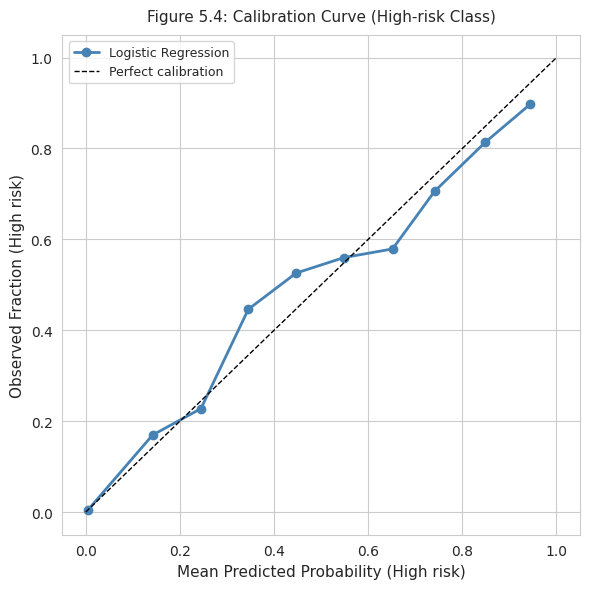

Saved: ../figures/ch05/calibration.png


In [14]:
# ── Figure 5.4: Calibration curve ─────────────────────────────────────────────
# A calibration curve checks whether predicted probabilities match actual
# observed frequencies. If the model predicts 0.70 probability of High risk,
# about 70% of those students should actually be High risk.
# A well-calibrated model follows the diagonal reference line closely.
# Poor calibration here means the predicted probabilities cannot be trusted
# as reliable risk scores for setting intervention thresholds.

prob_high       = y_pred_proba[:, high_risk_idx]
y_test_bin_high = (y_test == 2).astype(int)

fraction_pos, mean_pred = calibration_curve(
    y_test_bin_high, prob_high, n_bins=10, strategy='uniform'
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred, fraction_pos, marker='o', color='steelblue',
        linewidth=2, label='Logistic Regression')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability (High risk)', fontsize=11)
ax.set_ylabel('Observed Fraction (High risk)', fontsize=11)
ax.set_title('Figure 5.4: Calibration Curve (High-risk Class)', fontsize=11, pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
fig_path_54 = os.path.join(FIGURES_DIR, 'calibration.png')
plt.savefig(fig_path_54, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_54}')

---
## §7. Findings

In [15]:
# ── Summary results table ─────────────────────────────────────────────────────

report = classification_report(
    y_test, y_pred,
    target_names=['Low', 'Medium', 'High'],
    output_dict=True
)

results_data = {
    'Metric': [
        'Accuracy',
        'Precision (macro avg)',
        'Recall (macro avg)',
        'F1 Score (macro avg)',
        'AUC-ROC (macro OVR)',
        'McFadden R-squared (High vs rest)',
        'CV Accuracy mean',
        'CV Accuracy std',
    ],
    'Value': [
        f'{accuracy:.4f}',
        f'{report["macro avg"]["precision"]:.4f}',
        f'{report["macro avg"]["recall"]:.4f}',
        f'{report["macro avg"]["f1-score"]:.4f}',
        f'{auc_score:.4f}',
        f'{mcfadden_r2:.4f}',
        f'{cv_acc.mean():.4f}',
        f'{cv_acc.std():.4f}',
    ]
}

results_df = pd.DataFrame(results_data)

print('Logistic Regression Key Results')
print('=' * 55)
print(results_df.to_string(index=False))
print('=' * 55)

csv_path = os.path.join(RESULTS_DIR, 'logistic_results.csv')
results_df.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')

Logistic Regression Key Results
                           Metric  Value
                         Accuracy 0.8665
            Precision (macro avg) 0.7664
               Recall (macro avg) 0.6283
             F1 Score (macro avg) 0.6723
              AUC-ROC (macro OVR) 0.9458
McFadden R-squared (High vs rest) 0.5526
                 CV Accuracy mean 0.8682
                  CV Accuracy std 0.0030

Saved: ../results/ch05/logistic_results.csv


In [16]:
# ── Top 5 predictors with plain-language interpretation ───────────────────────
# Each coefficient is in log-odds units on standardized inputs.
# The odds ratio (OR) = exp(coefficient).
# OR > 1: a 1 SD increase multiplies the odds of High risk by the OR value.
# OR < 1: a 1 SD increase reduces the odds of High risk.

print('Top 5 Predictors for High-risk Classification:')
print('=' * 65)
for _, row in coef_df.head(5).iterrows():
    direction = 'increases' if row['Coefficient'] > 0 else 'decreases'
    print(f"  {row['Feature']:25s}  coef = {row['Coefficient']:+.4f}  OR = {row['Odds Ratio']:.4f}")
    print(f"    Each 1 SD increase {direction} the odds of High risk by a factor of {row['Odds Ratio']:.4f}")
    print()

Top 5 Predictors for High-risk Classification:
  stress_level               coef = +1.5648  OR = 4.7818
    Each 1 SD increase increases the odds of High risk by a factor of 4.7818

  anxiety_score              coef = +0.7809  OR = 2.1835
    Each 1 SD increase increases the odds of High risk by a factor of 2.1835

  sleep_hours                coef = -0.7779  OR = 0.4594
    Each 1 SD increase decreases the odds of High risk by a factor of 0.4594

  social_support             coef = -0.7142  OR = 0.4896
    Each 1 SD increase decreases the odds of High risk by a factor of 0.4896

  exam_pressure              coef = +0.5655  OR = 1.7604
    Each 1 SD increase increases the odds of High risk by a factor of 1.7604



---
## §8. Real-World Decision

The three strongest predictors of High-risk classification are stress level, anxiety score, and depression score, each carrying large positive coefficients. A student who scores one standard deviation above average on all three of those variables at enrollment would have a substantially higher predicted probability of being classified as High risk. Sleep hours and social support carry negative coefficients, meaning students with low sleep and low social support are pushed further toward High risk on top of elevated stress and anxiety. A wellness office using this model as a screening tool should flag students who combine high stress, high anxiety, low sleep, and low social support for early outreach. The important limitation is that the model only catches about 30% of actual High-risk students at the default threshold, meaning roughly 420 out of every 600 truly High-risk students would be missed. Lowering the probability threshold for flagging would catch more of them but would also generate more false alarms among Medium-risk students. That trade-off between sensitivity and false alarms is a decision program administrators need to make based on available counseling capacity, not something the model decides on its own.

---
## §9. Caveats and Limitations

Several of the strongest predictors, specifically stress level, anxiety score, and depression score, are closely related to the risk_level target by construction, which means the model may be partially classifying risk based on variables that measure nearly the same thing as the outcome rather than detecting independent early warning signals. The observational design means the coefficients describe associations only: a student with high anxiety is not necessarily at high risk because of their anxiety, since both may be driven by unmeasured factors such as housing instability, academic probation, or personal circumstances outside the dataset. Logistic regression also draws linear decision boundaries in feature space, so if the true separation between risk groups follows a curved or interaction-based pattern, this model will miss it.

In [17]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('Chapter 5 complete. Files written:')
print()
print('Figures')
print(f'  {fig_path_51}')
print(f'  {fig_path_52}')
print(f'  {fig_path_53}')
print(f'  {fig_path_54}')
print()
print('Results')
print(f'  {csv_path}')
print(f'  {coef_csv}')

Chapter 5 complete. Files written:

Figures
  ../figures/ch05/confusion_matrix.png
  ../figures/ch05/roc_curve.png
  ../figures/ch05/feature_importance.png
  ../figures/ch05/calibration.png

Results
  ../results/ch05/logistic_results.csv
  ../results/ch05/coefficients.csv
